In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


In [2]:
data = pd.read_csv("../dataset/IMDB Dataset.csv")


In [3]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
data.shape


(50000, 2)

In [5]:
data['sentiment'] = data['sentiment'].map({
    'positive':1,
    'negative':0
})


In [6]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


In [7]:
from sklearn.model_selection import train_test_split

# input and output
X = data['review']
y = data['sentiment']

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# check sizes
print("Training data:", len(X_train))
print("Testing data:", len(X_test))


Training data: 40000
Testing data: 10000


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

# create tokenizer
tokenizer = Tokenizer(num_words=10000)

# learn vocabulary
tokenizer.fit_on_texts(X_train)

# convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)



In [9]:
# check result
print("Example original text:")
print(X_train.iloc[0])

print("\nConverted sequence:")
print(X_train_seq[0])

Example original text:
That's what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I'm not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine's slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don't know what acting school they graduated from, but if I was them I'd apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we'll probably never hear from again. At least, that

In [11]:
X_train.head(1)

39087    That's what I kept asking myself during the ma...
Name: review, dtype: object

In [12]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# set maximum length
max_length = 200

# pad training data
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)

# pad testing data
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

# check shape
print("Training data shape:", X_train_pad.shape)
print("Testing data shape:", X_test_pad.shape)



Training data shape: (40000, 200)
Testing data shape: (10000, 200)


In [14]:
# check example
print("\nExample padded sequence:")
print(X_train_pad[0])



Example padded sequence:
[2946 3749 1828    2  147  144    3  228    4    3  207  323    2  144
 1083   16   88    4  132 2871 8743   18   10  153 9253   99    4    1
 4020  302   11   17 1001   35    1  496  492 2619  249   71   77  107
  107  698   60   86 1047 1363    5  229  132   23 4360   31  138  209
 1154   14 4501 5313   31    3 2386    2    8   11    6    3  445   14
  624    4    1  718 2959    1 1278    2   71 3616    1  166 1507    1
 1245    5 1629    1  879 1268    5    1  310  140 2894    2  410  633
    7    7    1  269    6 3553 1000    5   26   39   14 1381  217   65
    2   46    6   30  219   27  193 1484    8 1101   18   10 4905   84
    1  226   66  356   68   54   27    5 3600   15   44   21  192    5
 8255    3  889 3511 1758   22   25    5  158  196  175    3  110   12
 1652  471   75  221    5  325    2 3512   36   23   50   72 1889 4729
   14    9 1393   11   19    6    3 3554 2029   16   61    1 2436  470
  532    2    3  171 2577 2761 1778    5  585    9 

Compile the model


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Input(shape=(200,)))

model.add(Embedding(input_dim=10000, output_dim=128))

model.add(LSTM(128))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))




In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 198s 156ms/step - accuracy: 0.8036 - loss: 0.4340 - val_accuracy: 0.8708 - val_loss: 0.3158
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 157ms/step - accuracy: 0.8905 - loss: 0.2787 - val_accuracy: 0.8837 - val_loss: 0.2815
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 155ms/step - accuracy: 0.9220 - loss: 0.2046 - val_accuracy: 0.8863 - val_loss: 0.2805
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 155ms/step - accuracy: 0.9410 - loss: 0.1607 - val_accuracy: 0.8933 - val_loss: 0.2902
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 194s 155ms/step - accuracy: 0.9568 - loss: 0.1200 - val_accuracy: 0.8883 - val_loss: 0.3395


Model Evaluation

In [18]:

loss, accuracy = model.evaluate(X_test_pad, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8863 - loss: 0.2805


In [19]:
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 0.2805405557155609
Test Accuracy: 0.8863000273704529


Make predictions manually

In [20]:
sample_reviews = [
    "This movie is amazing",
    "This movie is terrible",
    "I really loved this film",
    "Worst movie ever"
]


In [21]:
seq = tokenizer.texts_to_sequences(sample_reviews)


In [22]:
pad = pad_sequences(seq, maxlen=200)


In [23]:
predictions = model.predict(pad)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step


In [24]:
for i in range(len(sample_reviews)):
    print(sample_reviews[i])
    print("Prediction:", predictions[i][0])
    print()


This movie is amazing
Prediction: 0.9160105

This movie is terrible
Prediction: 0.09531595

I really loved this film
Prediction: 0.905646

Worst movie ever
Prediction: 0.1429228



Convert prediction into label

In [25]:
for i in range(len(sample_reviews)):

    if predictions[i][0] > 0.5:
        print(sample_reviews[i], "→ its a Positive review")
    else:
        print(sample_reviews[i], "→ its a Negative review")


This movie is amazing → its a Positive review
This movie is terrible → its a Negative review
I really loved this film → its a Positive review
Worst movie ever → its a Negative review


confusion matrix

In [26]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print(cm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step
[[4348  613]
 [ 524 4515]]


Calculate Precision, Recall, F1 Score

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Visualize accuracy graph

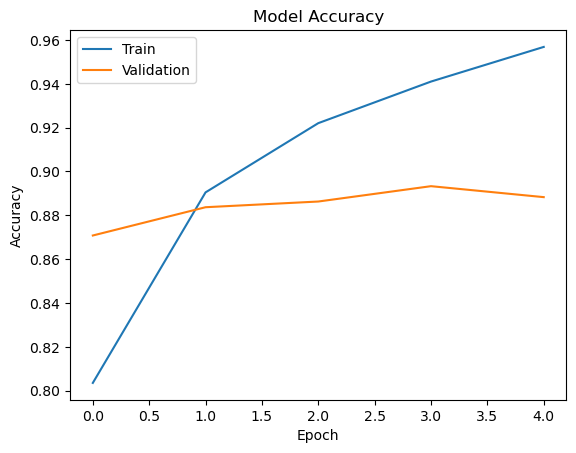

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()


Visualize loss graph

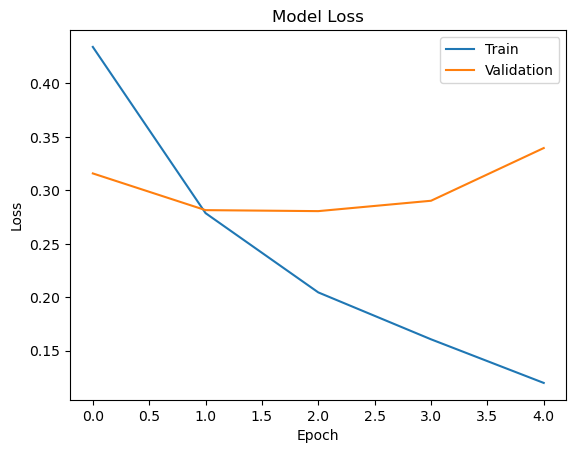

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()


In [30]:
model.save("../models/sentiment_lstm_model.keras")


In [31]:
import pickle

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved successfully")

Model and tokenizer saved successfully
